# Where does Stockfish 18 know a pin *matters*?

A **nonlinear (MLP) probe on every layer** of the Stockfish 18 NNUE forward pass.

For each position we ask a probe: *does this pin carry the Lichess `pin` theme tag?* —
i.e. is the pin **relevant**, not merely present. The probe is trained on one layer's
activations at a time, so the AUROC per layer is a readout of **how accessible that
property is at that point in the network**.

No handcrafted-geometry baseline, no null/random projections. The one non-layer
column is the **raw input** (§7) — the board encoding the network starts from,
without which a layer's score cannot be read as the network *adding* anything.

| | |
|---|---|
| **Positions** | 151,614 Lichess puzzles, each with exactly one sustained absolute pin |
| **Label** | the published Lichess `pin` theme, verbatim (28.48% positive) |
| **Probe** | `MLPClassifier`, one hidden config throughout, 5-fold stratified CV |
| **Metric** | ROC AUC (chance = 0.500), mean ± sd over folds |

## Provenance — where `dump.bin` comes from

The activations are dumped by a patched Stockfish 18. The full chain is vendored
next to this notebook so the result can be rebuilt from source:

| File | Role |
|---|---|
| `dumpnet.patch` | Stockfish 18 patch adding the `nnuedump` UCI command |
| `DUMPNET.md` | build + usage notes for the patched engine |
| `build_dataset.py` | puzzle filter → `fens.txt` + `meta.tsv` (labels) |
| `nnue_np.py` | numpy reader for the 10,780-byte `XAINNUE1` record |
| `data/dump.bin` | 151,614 records × every layer (1.6 GB, not in git) |

```bash
# 1. patched engine
git -C vendor/stockfish apply ../../sf-probe/dumpnet.patch && make -C vendor/stockfish/src -j8 build ARCH=x86-64-avx2
# 2. dataset (labels + FENs) from the Lichess puzzle CSV
zcat lichess_db_puzzle.csv.gz | python build_dataset.py
# 3. activations
printf 'nnuedump fens.txt data/dump.bin\nquit\n' | ./stockfish-xai-dbg
```

`dump.bin` is memory-mapped, so opening it costs no RAM.

## 1 · Configuration

Everything that changes a number lives in this one cell.

In [1]:
from pathlib import Path
import os, sys

# Repo-local package dir used by this project (harmless if absent).
_pylibs = Path.cwd().parent / ".pylibs"
if _pylibs.is_dir() and str(_pylibs) not in sys.path:
    sys.path.insert(0, str(_pylibs))
sys.path.insert(0, str(Path.cwd()))            # for nnue_np.py

HERE     = Path.cwd()
DUMP     = Path(os.environ.get("SF_PROBE_DUMP", HERE / "data" / "dump.bin"))
META     = Path(os.environ.get("SF_PROBE_META", HERE / "data" / "meta.tsv"))
OUT_JSON = HERE / "results_mlp.json"
OUT_CSV  = HERE / "results_mlp.csv"
OUT_PNG  = HERE / "layers_mlp.png"
CACHE    = HERE / "data" / "sweep.json"   # measured rows; delete one to retrain it

SEED  = 0        # seeds the CV split, the MLP init and its internal shuffling
FOLDS = 5

# One probe architecture for every layer — that is what makes the columns comparable.
MLP = dict(
    hidden_layer_sizes=(512, 128),
    activation="relu",
    solver="adam",
    alpha=1e-4,                 # L2
    batch_size=512,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,        # 10% of train held out to decide when to stop
    n_iter_no_change=15,
    validation_fraction=0.1,
    random_state=SEED,
)

# The raw input is 204,768-dim, so its first weight matrix is 105M params and a
# dense Adam update at batch 512 costs >11 min/epoch (~16 h for the sweep). The
# ONLY change for it is a larger batch — same architecture, same everything else.
# `l1` is re-run at this batch too, as a like-for-like control, so the input is
# never compared against a differently-trained number.
BIG_BATCH = 8192
MLP_BIG = dict(MLP, batch_size=BIG_BATCH)

assert DUMP.exists(), f"missing {DUMP} — see the provenance cell above"
print(f"dump {DUMP}  ({DUMP.stat().st_size/1e9:.2f} GB)")

dump /home/rharvey/Dokumente/Programmieren/xai-chess/sf-probe/data/dump.bin  (1.63 GB)


## 2 · Environment

Pinned versions, so a rerun that disagrees can be traced to a package.

In [2]:
import platform, numpy as np, scipy, sklearn, matplotlib

print(f"python       {platform.python_version()}")
for m in (np, scipy, sklearn, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")

# BLAS threads: set before the heavy cells so runtime is reproducible-ish.
os.environ.setdefault("OMP_NUM_THREADS", str(os.cpu_count()))
print(f"OMP_NUM_THREADS = {os.environ['OMP_NUM_THREADS']}")

python       3.12.3
numpy        2.5.2
scipy        1.18.1
sklearn      1.9.0
matplotlib   3.11.1
OMP_NUM_THREADS = 8


## 3 · Load activations and labels

In [3]:
import numpy as np
from nnue_np import load, probe_matrix, LAYERS as LAYER_DOC

acts = load(str(DUMP))                       # memmap — nothing read yet
y = np.loadtxt(META, delimiter="\t", skiprows=1, usecols=(2,), dtype=np.int8)

assert len(acts) == len(y), f"{len(acts)} records vs {len(y)} labels — misaligned"
N = len(y)
print(f"N = {N:,}   positive = {y.sum():,} ({y.mean()*100:.2f}%)   negative = {N-y.sum():,}")
print(f"chance AUROC = 0.500")

N = 151,614   positive = 43,177 (28.48%)   negative = 108,437
chance AUROC = 0.500


## 4 · The layers

The forward pass in order. `acc` and `tacc` are taken at **both perspectives**, because
that is what `l1` carries: `l1` is 1024 wide as 2 x 512 pairs, one per side. Reading the
accumulators at one perspective and `l1` at both would hand `l1` strictly more of the
position than its own inputs, and §7 shows exactly how much that is worth.

`acc||tacc` is their concatenation, which is the actual input to the first nonlinearity.

Note the **16-dim bottleneck**: after `l1` (1024 wide) everything the network
carries forward must fit through `fc0` (16 dims).

In [4]:
LAYER_ORDER = ["acc", "tacc", "acc||tacc", "l1", "fc0", "ac0", "fc1", "ac1", "fc2"]

NOTES = {
    "acc":       "accumulator, both perspectives: sum of active HalfKA weight columns + bias",
    "tacc":      "threat accumulator, both perspectives: same, over the FullThreats features",
    "acc||tacc": "concatenation, both perspectives — the full pre-nonlinearity state",
    "l1":        "clip(acc+tacc), then pairwise product /512 — first nonlinearity",
    "fc0":       "affine on l1; the 16-dim bottleneck (index 15 is the skip term)",
    "ac0":       "ac_sqr_0 || ac_0 — squared-clipped and clipped ReLU",
    "fc1":       "affine on ac0",
    "ac1":       "clipped ReLU",
    "fc2":       "affine to the scalar eval",
}

def layer_matrix(name, perspective="both"):
    """(N, D) float32 for one layer.

    `perspective` applies only to acc / tacc, the two layers the dump stores per side.
    "both" is the default because that is the form l1 is stored in.
    """
    if name.startswith("acc||tacc"):
        return np.hstack([probe_matrix(acts, "acc", perspective),
                          probe_matrix(acts, "tacc", perspective)])
    if name in ("acc", "tacc"):
        return probe_matrix(acts, name, perspective)
    return probe_matrix(acts, name)

# acc/tacc are per-perspective in the dump, so their probed width is twice the stored
# one; probe_matrix would have to be called with the layer name to learn that, and
# "acc||tacc" is not a field at all.
WIDE = {"acc": 2048, "tacc": 2048, "acc||tacc": 4096}

print(f"{'layer':11} {'dims':>6}  what it is")
for nm in LAYER_ORDER:
    d = WIDE[nm] if nm in WIDE else probe_matrix(acts, nm).shape[1]
    print(f"{nm:11} {d:>6}  {NOTES[nm]}")

layer         dims  what it is
acc           2048  accumulator, both perspectives: sum of active HalfKA weight columns + bias
tacc          2048  threat accumulator, both perspectives: same, over the FullThreats features
acc||tacc     4096  concatenation, both perspectives — the full pre-nonlinearity state
l1            1024  clip(acc+tacc), then pairwise product /512 — first nonlinearity
fc0             16  affine on l1; the 16-dim bottleneck (index 15 is the skip term)
ac0             30  ac_sqr_0 || ac_0 — squared-clipped and clipped ReLU
fc1             32  affine on ac0
ac1             32  clipped ReLU
fc2              1  affine to the scalar eval


## 5 · The probe

One `MLPClassifier` per fold per layer. Features are standardised on the training
fold only (the scaler never sees the test fold), and the CV split is identical for
every layer, so the layers are compared on exactly the same partition.

In [5]:
import time, gc, json
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold

# Identical splits for every layer.
SPLITS = list(StratifiedKFold(FOLDS, shuffle=True, random_state=SEED).split(np.zeros(N), y))

def probe(X, cfg=None, scale=True):
    """5-fold CV MLP. Returns (mean AUROC, sd AUROC, mean accuracy, mean epochs).

    scale=False for the sparse input: it is already binary 0/1, and centring it
    would densify a 204,768-column matrix.
    """
    cfg = cfg or MLP
    au, ac, it = [], [], []
    for tr, te in SPLITS:
        if scale:
            sc = StandardScaler().fit(X[tr])
            Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        else:
            sc, Xtr, Xte = None, X[tr], X[te]
        m = MLPClassifier(**cfg).fit(Xtr, y[tr])
        p = m.predict_proba(Xte)[:, 1]
        au.append(roc_auc_score(y[te], p))
        ac.append(accuracy_score(y[te], (p >= 0.5).astype(np.int8)))
        it.append(m.n_iter_)
        del sc, Xtr, Xte, m, p; gc.collect()
    return float(np.mean(au)), float(np.std(au)), float(np.mean(ac)), float(np.mean(it))


# Every number below is one 5-fold run, and a full retrain is ~90 minutes. The rows are
# therefore cached as they are measured, so re-running the notebook to change the plot,
# the table or the prose costs seconds. Delete an entry in data/sweep.json (or the whole
# file) to force that column to be measured again.
def measured(name, build, cfg=None, scale=True, note=""):
    """The row for `name`, trained only if the cache does not already hold it."""
    store = json.loads(CACHE.read_text()) if CACHE.exists() else {}
    if name in store:
        r = store[name]
        print(f"{name:16} {r['dims']:>7} {r['auroc']:>8.4f} {r['sd']:>7.4f} "
              f"{r['acc']:>7.4f}   restored ({r.get('source', 'cache')})", flush=True)
        return r
    X = build()
    t = time.time()
    auroc, sd, acc, epochs = probe(X, cfg, scale)
    r = dict(layer=name, dims=int(X.shape[1]), auroc=auroc, sd=sd, acc=acc,
             epochs=epochs, secs=time.time() - t, note=note,
             batch=(cfg or MLP)["batch_size"], source="measured this run")
    del X; gc.collect()
    print(f"{name:16} {r['dims']:>7} {auroc:>8.4f} {sd:>7.4f} {acc:>7.4f} "
          f"{r['secs']:>8.1f}s", flush=True)
    store[name] = r
    CACHE.parent.mkdir(exist_ok=True)
    CACHE.write_text(json.dumps(store, indent=1))
    return r

## 6 · Run the sweep

~1 minute per fold on the wide layers; the whole sweep is well under an hour on 8 cores.

In [6]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

rows, t0 = [], time.time()
for nm in LAYER_ORDER:
    rows.append(measured(nm, lambda nm=nm: layer_matrix(nm), note=NOTES[nm]))

print(f"\ntotal {(time.time()-t0)/60:.1f} min")

acc                 2048   0.8208  0.0014  0.7822   restored (perspective.py, 2026-09-02)


tacc                2048   0.8303  0.0035  0.7903   restored (perspective.py, 2026-09-02)


acc||tacc           4096   0.8389  0.0020  0.7959   restored (perspective.py, 2026-09-02)


l1                  1024   0.8164  0.0043  0.7870   restored (probe_mlp.ipynb sweep, 2026-09-01)


fc0                   16   0.6559  0.0015  0.7261   restored (probe_mlp.ipynb sweep, 2026-09-01)


ac0                   30   0.6396  0.0071  0.7240   restored (probe_mlp.ipynb sweep, 2026-09-01)


fc1                   32   0.6333  0.0062  0.7221   restored (probe_mlp.ipynb sweep, 2026-09-01)


ac1                   32   0.5965  0.0084  0.7184   restored (probe_mlp.ipynb sweep, 2026-09-01)


fc2                    1   0.5257  0.0048  0.7152   restored (probe_mlp.ipynb sweep, 2026-09-01)



total 0.0 min


## 7 · The perspective control — what the first pass got wrong

The first pass of this sweep read `acc` and `tacc` at the **side-to-move perspective
only**, 1024 dims each, while `l1` is stored as 2 x 512 pairs covering **both** sides.
`l1` was therefore handed strictly more of the position than the layers it is computed
from, and the conclusion drawn from that — "`l1` clears the best pre-`l1` representation
by +0.022" — was measuring the missing perspective, not the nonlinearity.

This section keeps the first pass as a control and puts it next to the fair comparison
the sweep above now uses. The gap it opens is worth more than the entire spread across
the wide layers.

In [7]:
# The three columns as the first pass read them: one perspective, half the position.
stm = [measured(f"{nm} @ stm", lambda nm=nm: layer_matrix(nm, "stm"),
                note="side-to-move perspective only — the first pass, kept as a control")
       for nm in ("acc", "tacc", "acc||tacc")]

fair = {r["layer"]: r for r in rows}
l1   = fair["l1"]
print(f"\n{'':11} {'side to move':>22} {'both perspectives':>24} {'gain':>9}")
for r in stm:
    nm = r["layer"].replace(" @ stm", "")
    f  = fair[nm]
    print(f"{nm:11} {r['auroc']:>12.4f} ({r['dims']:>4}d) "
          f"{f['auroc']:>14.4f} ({f['dims']:>4}d) {f['auroc']-r['auroc']:>+9.4f}")

best_pre = max((fair[n] for n in ("acc", "tacc", "acc||tacc")), key=lambda r: r["auroc"])
worst_stm = max(stm, key=lambda r: r["auroc"])
print(f"\nbest pre-l1, one perspective : {worst_stm['layer']:16} {worst_stm['auroc']:.4f}"
      f"   ->  l1 leads by {l1['auroc']-worst_stm['auroc']:+.4f}   (the claim the first pass made)")
print(f"best pre-l1, both perspectives: {best_pre['layer']:16} {best_pre['auroc']:.4f}"
      f"   ->  l1 leads by {l1['auroc']-best_pre['auroc']:+.4f}   (the fair comparison)")

acc @ stm           1024   0.7601  0.0023  0.7521   restored (probe_mlp.ipynb sweep, 2026-09-01)


tacc @ stm          1024   0.7875  0.0018  0.7688   restored (probe_mlp.ipynb sweep, 2026-09-01)


acc||tacc @ stm     2048   0.7939  0.0023  0.7691   restored (probe_mlp.ipynb sweep, 2026-09-01)



                      side to move        both perspectives      gain
acc               0.7601 (1024d)         0.8208 (2048d)   +0.0607
tacc              0.7875 (1024d)         0.8303 (2048d)   +0.0428
acc||tacc         0.7939 (2048d)         0.8389 (4096d)   +0.0450

best pre-l1, one perspective : acc||tacc @ stm  0.7939   ->  l1 leads by +0.0225   (the claim the first pass made)
best pre-l1, both perspectives: acc||tacc        0.8389   ->  l1 leads by -0.0225   (the fair comparison)


## 8 · The raw input — the reference the layers have to beat

The layer sweep alone cannot tell you whether the network *adds* anything: a layer
scoring 0.816 is only impressive if the board encoding it was computed from scores
less. So we probe the **input** itself.

This is the exact sparse feature vector Stockfish is handed, reconstructed from the
dumped active indices:

| | |
|---|---|
| HalfKAv2_hm | 22,528 = 11 pieces × 64 squares × 32 king buckets |
| FullThreats | 79,856 |
| per perspective | 102,384 — matches the net header `(102384, 1024, 15, 32, 1)` |
| **both perspectives** | **204,768** |

It is extremely sparse (~97 nonzeros per row), so it costs 59 MB as CSR.

Two things to keep straight: the input is **not a layer** — it is what the network
starts from, before any learned weight touches it. And `acc`/`tacc` *are* the
network's own learned linear projection of exactly this vector.

In [8]:
import scipy.sparse as sp

KA, TH = 22528, 79856          # HalfKAv2_hm span, FullThreats span
PER    = KA + TH               # 102,384 per perspective

def build_input():
    """Reconstruct the exact sparse input from the dumped active feature indices."""
    rows, cols = [], []
    for p in range(2):
        for arr, cnt, off in ((acts["idx_halfka"][:, p, :],  acts["n_halfka"][:, p],  0),
                              (acts["idx_threats"][:, p, :], acts["n_threats"][:, p], KA)):
            k = np.asarray(cnt, dtype=np.int64)
            mask = np.arange(arr.shape[1])[None, :] < k[:, None]
            rows.append(np.repeat(np.arange(N), k))
            cols.append(np.asarray(arr)[mask].astype(np.int64) + off + p * PER)
    r, c = np.concatenate(rows), np.concatenate(cols)
    return sp.csr_matrix((np.ones(len(r), np.float32), (r, c)), shape=(N, 2 * PER))

# Skip the reconstruction entirely when the two rows that need it are already measured:
# it is a minute of work and 118 MB that nothing downstream would read.
_have = json.loads(CACHE.read_text()) if CACHE.exists() else {}
if {"input", "l1 @ batch %d" % BIG_BATCH} <= set(_have):
    X_in = None
    print(f"input matrix not built — both rows are already in {CACHE.name}")
else:
    X_in = build_input()
    print(f"input: {X_in.shape[0]:,} x {X_in.shape[1]:,}   nnz {X_in.nnz:,} "
          f"({X_in.nnz/N:.1f} per row)   "
          f"{(X_in.data.nbytes+X_in.indices.nbytes)/1e6:.0f} MB")

# The span is fixed by the feature set, so this holds whether or not the matrix was built.
print(f"first-layer params of MLP{MLP['hidden_layer_sizes']} on it: "
      f"{2*PER*MLP['hidden_layer_sizes'][0]/1e6:.1f}M  "
      f"(Stockfish's own feature transformer: {PER*1024/1e6:.1f}M)")

input matrix not built — both rows are already in sweep.json
first-layer params of MLP(512, 128) on it: 104.8M  (Stockfish's own feature transformer: 104.8M)


In [9]:
extra, t0 = [], time.time()

# The input, at the larger batch (the only deviation).
extra.append(measured("input", lambda: X_in, cfg=MLP_BIG, scale=False,
                      note="raw sparse board encoding (not a layer)"))

# Like-for-like control: l1 trained at the SAME batch, so input-vs-l1 is not a
# comparison between two different training regimes.
extra.append(measured("l1 @ batch %d" % BIG_BATCH, lambda: layer_matrix("l1"),
                      cfg=MLP_BIG, note="control: same batch as the input run"))

print(f"\ntotal {(time.time()-t0)/60:.1f} min")

input             204768   0.7951  0.0047  0.7708   restored (probe_mlp.ipynb sweep, 2026-09-01)


l1 @ batch 8192     1024   0.8137  0.0013  0.7842   restored (probe_mlp.ipynb sweep, 2026-09-01)



total 0.0 min


## 9 · Results

In [10]:
import csv

for r in rows + stm + extra:
    r.setdefault("batch", MLP["batch_size"])
all_rows = rows + extra + stm          # the ladder, the input, then the control

best = max(rows, key=lambda r: r["auroc"])          # best *layer*
inp   = next(r for r in all_rows if r["layer"] == "input")
ctrl  = next(r for r in all_rows if r["layer"].startswith("l1 @"))

meta = dict(
    n=int(N), positive=int(y.sum()), positive_rate=float(y.mean()),
    folds=FOLDS, seed=SEED, probe="MLPClassifier",
    mlp={k: str(v) for k, v in MLP.items()}, big_batch=BIG_BATCH,
    best_layer=best["layer"], best_auroc=best["auroc"],
    input_auroc=inp["auroc"], l1_control_auroc=ctrl["auroc"],
    perspective="both for acc/tacc — the form l1 is stored in; the @ stm rows are the "
                "first pass, kept as a control",
)
json.dump(dict(meta=meta, rows=all_rows), open(OUT_JSON, "w"), indent=1)
with open(OUT_CSV, "w", newline="") as f:
    fn = ["layer", "dims", "auroc", "sd", "acc", "epochs", "secs", "batch",
          "source", "note"]
    w = csv.DictWriter(f, fieldnames=fn)
    w.writeheader(); w.writerows({k: r.get(k) for k in fn} for r in all_rows)

print(f"best layer : {best['layer']} at {best['auroc']:.4f} ± {best['sd']:.4f}")
print(f"raw input  : {inp['auroc']:.4f} ± {inp['sd']:.4f}")
print(f"l1 control : {ctrl['auroc']:.4f} ± {ctrl['sd']:.4f}   (same batch as the input run)")
print(f"\ninput - l1(like-for-like) = {inp['auroc']-ctrl['auroc']:+.4f}\n")
print(f"{'row':22} {'dims':>7} {'AUROC':>16}")
for r in all_rows:
    bar = "#" * round((r["auroc"] - 0.5) * 120)
    print(f"{r['layer']:22} {r['dims']:>7}   {r['auroc']:.4f} ± {r['sd']:.4f}  {bar}")
print(f"\nwrote {OUT_JSON.name}, {OUT_CSV.name}")

best layer : acc||tacc at 0.8389 ± 0.0020
raw input  : 0.7951 ± 0.0047
l1 control : 0.8137 ± 0.0013   (same batch as the input run)

input - l1(like-for-like) = -0.0186

row                       dims            AUROC
acc                       2048   0.8208 ± 0.0014  ######################################
tacc                      2048   0.8303 ± 0.0035  ########################################
acc||tacc                 4096   0.8389 ± 0.0020  #########################################
l1                        1024   0.8164 ± 0.0043  ######################################
fc0                         16   0.6559 ± 0.0015  ###################
ac0                         30   0.6396 ± 0.0071  #################
fc1                         32   0.6333 ± 0.0062  ################
ac1                         32   0.5965 ± 0.0084  ############
fc2                          1   0.5257 ± 0.0048  ###
input                   204768   0.7951 ± 0.0047  ###################################
l1 @ batch 81

## 10 · Plot

In [11]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dedcd6"
# Sequential blue ramp, darkest = highest AUROC (magnitude, one hue).
RAMP = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6",
        "#256abf", "#1c5cab", "#184f95", "#0d366b"]

INPUT_C = "#8a8a84"                                       # the input is not a layer
plot_rows = [inp] + rows                                  # input first, then the pass
names  = ["input"] + [r["layer"] for r in rows]
vals   = np.array([r["auroc"] for r in plot_rows])
sds    = np.array([r["sd"] for r in plot_rows])
dims   = [r["dims"] for r in plot_rows]
x      = np.arange(len(names))
lay    = np.array([r["auroc"] for r in rows])
colors = [INPUT_C] + [RAMP[i] for i in lay.argsort().argsort()]
peak   = 1 + int(lay.argmax())                            # best layer, offset past input

fig, ax = plt.subplots(figsize=(12.6, 5.8))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")

# The 16-dim bottleneck: everything from fc0 rightwards lives downstream of it.
i_fc0 = names.index("fc0")
ax.axvspan(i_fc0 - 0.5, len(names) - 0.5, color="#f4f3ef", zorder=0)
# The input is the board before any learned weight touches it — keep it apart.
ax.vlines(0.5, 0.5, 0.5 + (max(r["auroc"] for r in plot_rows) - 0.5) * 1.02,
          color="#c9c8c2", lw=1.1, zorder=2)

ax.bar(x, vals - 0.5, bottom=0.5, width=0.66, color=colors, zorder=3)
ax.errorbar(x, vals, yerr=sds, fmt="none", ecolor="#ffffff", elinewidth=1.6,
            capsize=0, zorder=4)
ax.errorbar(x, vals, yerr=sds, fmt="none", ecolor=INK, elinewidth=0.9,
            capsize=3, alpha=.55, zorder=5)

import matplotlib.patheffects as pe
# A white halo so the raw-input reference line cannot strike through a value label.
HALO = [pe.withStroke(linewidth=3.4, foreground="white")]
for i, v in enumerate(vals):
    ax.text(i, v + sds[i] + 0.004, f"{v:.3f}", ha="center", fontsize=9.5,
            color=INK, weight="bold" if i == peak else "normal", zorder=7,
            path_effects=HALO)

# The line every layer has to clear: what the raw board encoding already gives you.
v_in = inp["auroc"]
ax.hlines(v_in, 0.5, len(names) - 0.4, color=INPUT_C, lw=1.6, zorder=6)
ax.text(len(names) - 0.35, v_in, f" raw input\n {v_in:.3f}", fontsize=9.0,
        color=INPUT_C, va="center", ha="left", weight="bold")

ax.text(0, 0.5 + (vals.max() - 0.5) * 1.075, "the board,\nbefore the network",
        fontsize=8.8, color=INPUT_C, ha="center", style="italic", zorder=7,
        path_effects=HALO)
ax.text((i_fc0 + len(names) - 1) / 2, 0.5 + (vals.max() - 0.5) * 1.19,
        "the 16-dim bottleneck, and everything after it", fontsize=9.4, color=MUTED,
        ha="center", style="italic")

ax.set_xticks(x)
ax.set_xticklabels([f"{n}\n{d:,}d" for n, d in zip(names, dims)], fontsize=9.6, color=INK)
ax.set_ylabel("ROC AUC   (5-fold CV, mean ± sd)", fontsize=10.5, color=INK)
ax.set_ylim(0.5, 0.5 + (vals.max() - 0.5) * 1.30)
ax.tick_params(axis="y", labelsize=9.5, colors=MUTED, length=0)
ax.tick_params(axis="x", length=0)
ax.grid(axis="y", color=GRID, lw=0.7, zorder=1)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)

# Title block drawn as explicit stacked text — set_title + a multi-line subtitle
# collide, because pad cannot know how tall the subtitle is.
ax.text(0, 1.155, "Where is a pin's relevance readable in Stockfish 18?",
        transform=ax.transAxes, fontsize=14, color=INK, va="bottom", weight="bold")
ax.text(0, 1.015,
        f"MLP probe on the raw input and on every NNUE layer · {N:,} Lichess puzzles, "
        f"one sustained pin each · {y.mean()*100:.2f}% carry the `pin` tag\n"
        f"probe = MLP{MLP['hidden_layer_sizes']} held identical throughout · "
        f"{FOLDS}-fold stratified CV · acc and tacc at both perspectives, the form l1 is "
        f"stored in · darker = higher · axis starts at chance (0.500)",
        transform=ax.transAxes, fontsize=9.6, color=MUTED, va="bottom", linespacing=1.5)

fig.savefig(OUT_PNG, dpi=170, bbox_inches="tight", facecolor="white")
print(f"wrote {OUT_PNG}")
plt.close(fig)

wrote /home/rharvey/Dokumente/Programmieren/xai-chess/sf-probe/layers_mlp.png


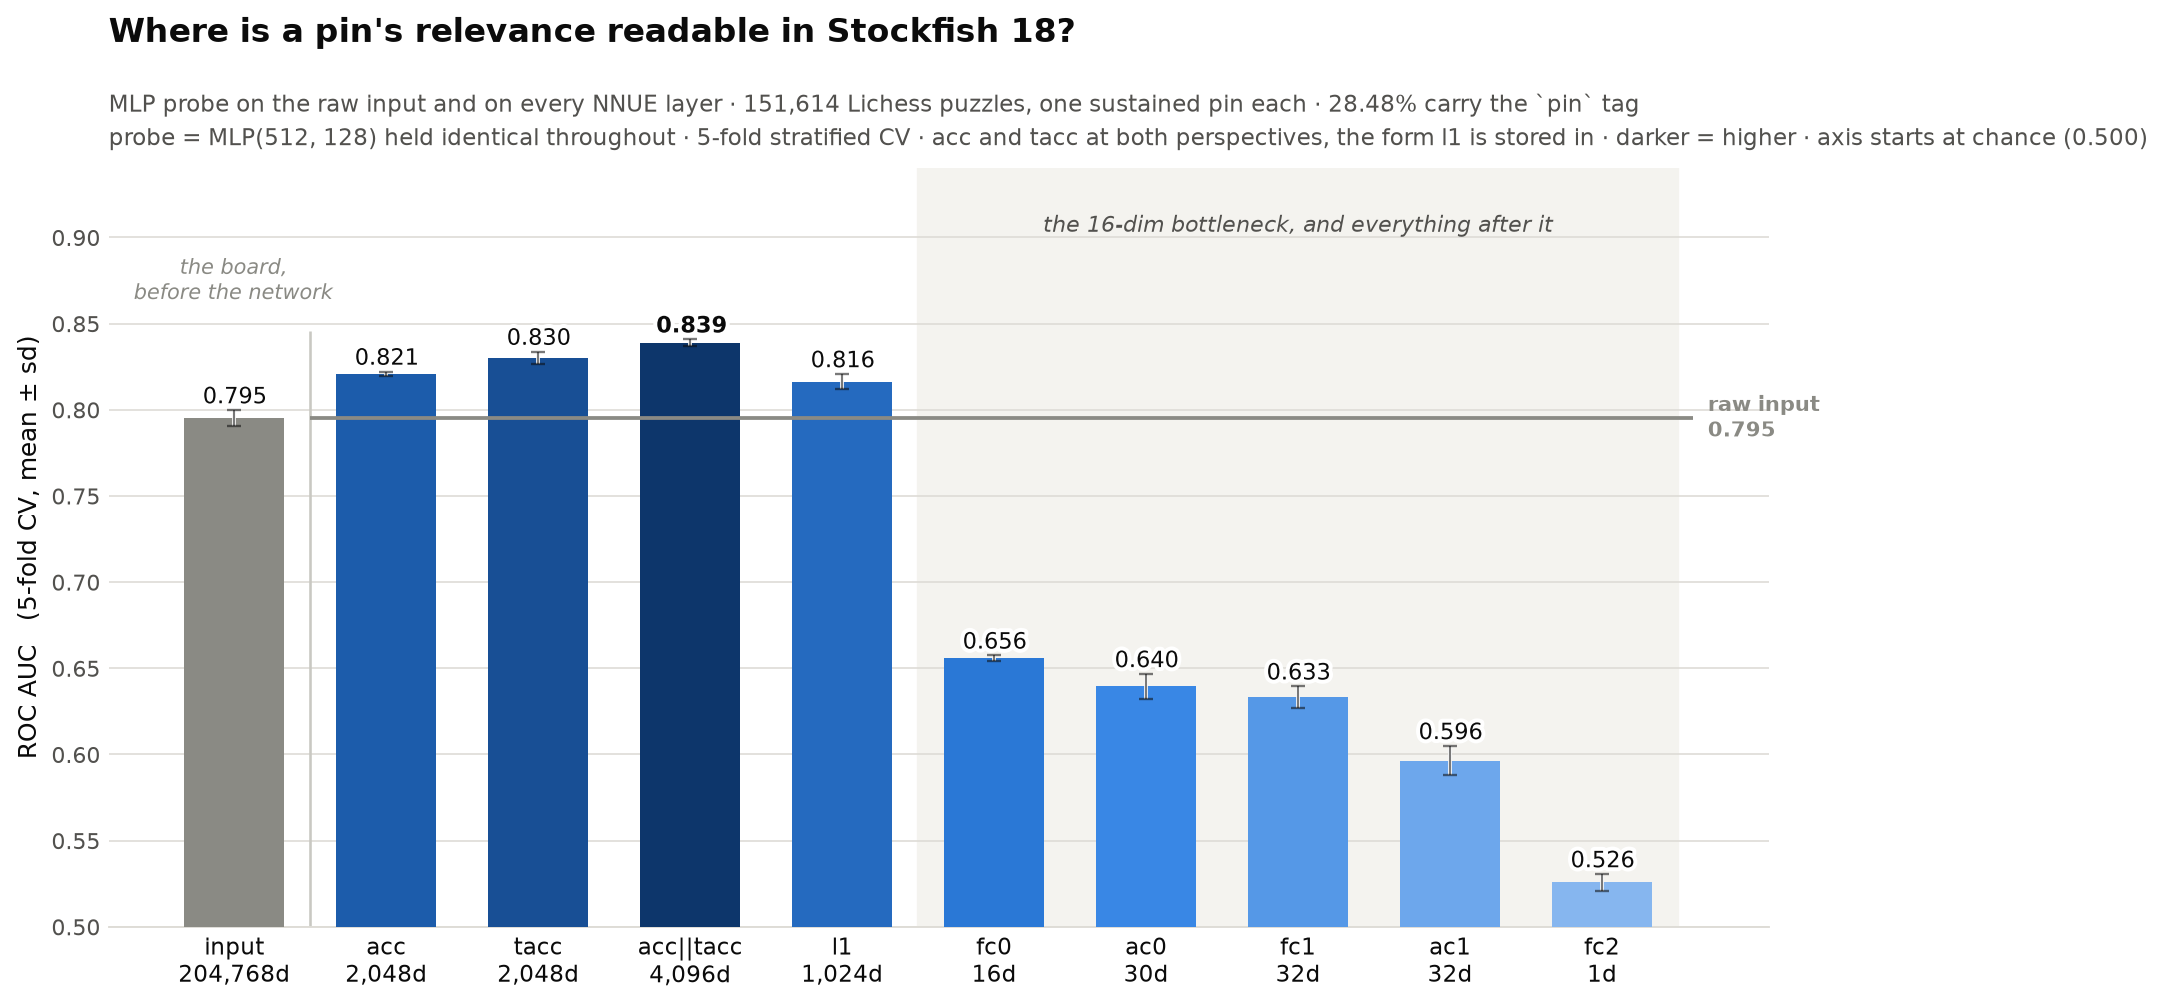

In [12]:
from IPython.display import Image, display
display(Image(filename=str(OUT_PNG)))

## 11 · Reading it

The probe is identical at every column, so a difference between columns is a
difference in the **representation**, not in the classifier.

### The layers

- **The accumulators beat `l1`, not the other way round.** `acc||tacc` reaches 0.839,
  `l1` 0.816: the first nonlinearity does not make pin relevance more accessible than
  the state it is computed from, it makes it **less** so. Each accumulator on its own
  also clears `l1` (`acc` 0.821, `tacc` 0.830). `l1` takes 4096 numbers to 1024 and
  loses 0.023 of readable pin relevance doing it.
- **This reverses the first pass, and §7 says why.** Reading `acc`/`tacc` at the
  side-to-move perspective only gave 0.760 / 0.788 / 0.794 and made `l1` look like the
  best layer by +0.022. That gap was the missing perspective: `l1` is stored as both
  sides, so it was being handed a position its own inputs had been denied. Restoring
  the perspective moves the three columns +0.061 / +0.043 / +0.045 and flips the sign
  of the comparison to −0.023.
- **It is not simply that wider probes win.** `acc` at 2048 dims beats `l1` at 1024,
  which invites the objection that the probe just has more first-layer capacity. But
  `l1` was benchmarked at (1024, 256) — double the hidden capacity — and reached 0.824,
  still under `tacc` alone at 0.830 and well under `acc||tacc` at 0.839.
- **The 16-dim bottleneck is a cliff, not a slope.** `l1` → `fc0` drops **0.160**. The
  decay then continues monotonically (0.656 → 0.640 → 0.633 → 0.596) to 0.526 at
  `fc2`. The scalar eval retains almost nothing about whether the pin mattered.
- **`tacc` (0.830) beats `acc` (0.821)** — the threat features are the input family a
  pin lives in. Concatenating both adds only +0.009 over `tacc` alone, so the two
  accumulators are largely redundant for this property.

### The input — and a reversal against the linear probe

| probe | raw input | `l1` | winner |
|---|---|---|---|
| linear (logistic regression) | 0.787 | 0.769 | **input** by +0.018 |
| MLP (512, 128) | 0.795 | **0.814** † | **`l1`** by +0.019 |

† `l1` retrained at the input's batch size, so this is like-for-like. At the
sweep's own batch `l1` is 0.816; the batch change costs it only −0.003.

Under a *linear* readout the raw board beat every layer — the network looked like it
was destroying accessibility, not creating it. Under a *nonlinear* readout that
ordering flips: `l1` is ahead of the input by about the same margin, and the
accumulators are ahead of it by more (`acc||tacc` − input = **+0.044**).

The mechanism is in how much each column gains from the extra capacity:

| | linear → MLP |
|---|---|
| raw input | 0.787 → 0.795 (**+0.008**) |
| `l1` | 0.769 → 0.816 (**+0.047**) |

So no layer holds *more* information than the board — none can, they are all functions
of it. They hold it in a form a small nonlinear reader can get at. The accumulators do
that best; every stage after them gives some of it back.

### Why the input number is a lower bound, not a measurement

Read the input column as a floor. Three reasons it is the least-converged of the
columns:

1. Its first weight matrix is **105M params** (204,768 × 512) against `l1`'s 0.5M.
2. It is the only column trained at **batch 8192** rather than 512 — 16× fewer
   Adam updates per epoch — because at batch 512 a dense update costs >11 min/epoch
   (~16 h for the sweep).
3. It is unscaled (correctly — the features are binary, and centring would densify a
   204,768-column matrix), and it stopped after 20.4 epochs on average.

The `l1` control bounds the *batch* effect at −0.003, but `l1` is a far easier
optimisation problem, so that bound does not transfer cleanly to a 105M-param
first layer. The honest statement is therefore: **every wide layer ≥ input under
matched settings**, and closing that gap would take a probe trained the way you would
train a real model on sparse features — embedding-bag first layer, sparse gradients —
not `sklearn`.

### What none of this shows

The label is the published Lichess `pin` theme: machine-assigned, then vote-filtered.
The ceiling is agreement with **that tagger**, not ground truth about whether a pin
mattered.

And a probe is a **decoder, not a cause**. Recoverability does not establish that the
network *uses* the property. Testing that needs intervention, not probing.